# 04 — Diễn giải mô hình và phân tích lỗi

Notebook này đọc đúng artifact và test prediction đã khóa ở notebook 03. Mục tiêu không chỉ là xếp hạng feature mà còn xác định mô hình sai ở đâu và liệu sai số có bất cân xứng giữa các nhóm hay không.

In [1]:
from pathlib import Path
import os, sys, json, warnings

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = ROOT / "data" / "train.csv"
TEST_PATH = ROOT / "data" / "test.csv"
TARGET = "Loan Sanction Amount (USD)"
REQUEST = "Loan Amount Request (USD)"
RANDOM_STATE = 42

df_raw = pd.read_csv(TRAIN_PATH)
df_external = pd.read_csv(TEST_PATH)
print(f"Train: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print(f"Test ngoài: {df_external.shape[0]:,} dòng x {df_external.shape[1]} cột")

Train: 30,000 dòng x 24 cột
Test ngoài: 20,000 dòng x 23 cột


In [2]:
SENTINEL = -999
DROP_COLUMNS = ["Customer ID", "Name", "Property ID", "Gender"]
BASE_FEATURES = [
    "Age", "Income (USD)", "Income Stability", "Profession",
    "Type of Employment", "Location", REQUEST,
    "Current Loan Expenses (USD)", "Expense Type 1", "Expense Type 2",
    "Dependents", "Credit Score", "No. of Defaults",
    "Has Active Credit Card", "Property Age", "Property Type",
    "Property Location", "Co-Applicant", "Property Price",
]
ENGINEERED_FEATURES = [
    "RequestToIncome", "RequestToProperty", "ExpenseToIncome",
    "IncomePerDependent", "PropertyEquityProxy", "CreditIncomeInteraction",
    "CreditRequestInteraction", "AgeIncomeInteraction",
]

def normalize_missing(df):
    out = df.copy()
    out = out.replace(SENTINEL, np.nan)
    return out

def add_business_features(df):
    out = normalize_missing(df)
    eps = 1e-6
    income = out["Income (USD)"].clip(lower=eps)
    request = out[REQUEST].clip(lower=0)
    property_price = out["Property Price"].clip(lower=eps)
    expenses = out["Current Loan Expenses (USD)"].clip(lower=0)
    dependents = out["Dependents"].clip(lower=0).fillna(0)
    credit = out["Credit Score"]

    out["RequestToIncome"] = request / income
    out["RequestToProperty"] = request / property_price
    out["ExpenseToIncome"] = expenses / income
    out["IncomePerDependent"] = income / (dependents + 1)
    out["PropertyEquityProxy"] = property_price - request
    out["CreditIncomeInteraction"] = credit * np.log1p(income)
    out["CreditRequestInteraction"] = credit / (request + 1) * 1000
    out["AgeIncomeInteraction"] = out["Age"] * np.log1p(income)
    return out

def modeling_frame(df):
    out = add_business_features(df)
    columns = [c for c in BASE_FEATURES + ENGINEERED_FEATURES if c in out.columns]
    return out[columns].copy()

def valid_regression_rows(df):
    target = pd.to_numeric(df[TARGET], errors="coerce")
    return target.notna() & (target > 0)

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_squared_log_error,
)

def build_preprocessor(X, scale_numeric=False):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

def regression_metrics(y_true, y_pred, requested=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1.0)
    result = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "rmsle": np.sqrt(mean_squared_log_error(np.maximum(y_true, 0), np.maximum(y_pred, 0))),
        "wape": abs_error.sum() / np.abs(y_true).sum(),
        "within_10pct": np.mean(abs_error / denom <= 0.10),
        "within_20pct": np.mean(abs_error / denom <= 0.20),
        "mean_signed_error": np.mean(y_pred - y_true),
        "over_rate": np.mean(y_pred > y_true),
    }
    if requested is not None:
        requested = np.asarray(requested, dtype=float)
        result["above_request_rate"] = np.mean(y_pred > requested)
    return result

def apply_policy(raw_prediction, requested, property_price=None, max_ltv=0.90):
    prediction = np.maximum(np.asarray(raw_prediction, dtype=float), 0)
    prediction = np.minimum(prediction, np.asarray(requested, dtype=float))
    if property_price is not None:
        valid_property = np.asarray(property_price, dtype=float)
        cap = np.where(np.isfinite(valid_property) & (valid_property > 0), valid_property * max_ltv, np.inf)
        prediction = np.minimum(prediction, cap)
    return prediction

In [4]:
import joblib

artifact_path = ROOT / "outputs" / "notebook_artifacts" / "best_model.joblib"
prediction_path = ROOT / "outputs" / "reports" / "internal_test_predictions.csv"
artifact = joblib.load(artifact_path)
predictions = pd.read_csv(prediction_path, index_col="source_index")
pipeline = artifact["pipeline"]
model_name = artifact["model_name"]
print(f"Model: {model_name} | Test rows: {len(predictions):,}")

Model: RandomForest | Test rows: 3,219


## 1. Permutation importance trên dữ liệu gốc

,feature,importance_mean,importance_std
6,Loan Amount Request (USD),"39,784.989",311.753
11,Credit Score,"1,970.547",78.143
18,Property Price,"1,011.749",23.097
25,CreditRequestInteraction,238.872,22.201
7,Current Loan Expenses (USD),8.097,2.870
17,Co-Applicant,3.947,1.061
16,Property Location,2.519,1.244
5,Location,1.317,1.376
2,Income Stability,0.885,0.177
12,No. of Defaults,0.786,0.821


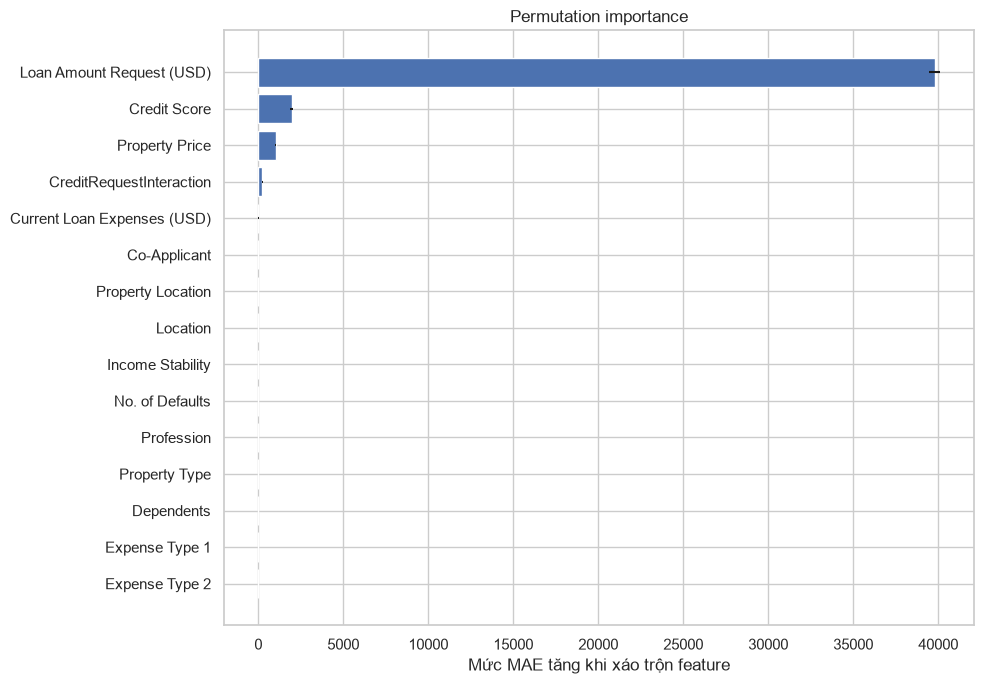

In [5]:
from sklearn.inspection import permutation_importance

X_test = modeling_frame(predictions)
y_test = predictions[TARGET]
perm = permutation_importance(
    pipeline, X_test, y_test,
    scoring="neg_mean_absolute_error", n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=1,
)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
display(perm_df.head(20))

plt.figure(figsize=(10, 7))
top = perm_df.head(15).sort_values("importance_mean")
plt.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
plt.xlabel("Mức MAE tăng khi xáo trộn feature")
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

## 2. SHAP trên không gian sau preprocessing

 32%|======              | 160/500 [00:11<00:23]       

 35%|=======             | 175/500 [00:12<00:22]       

 38%|========            | 190/500 [00:13<00:21]       

 41%|========            | 205/500 [00:14<00:20]       

 44%|=========           | 219/500 [00:15<00:19]       

...

 88%|==================  | 439/500 [00:30<00:04]       

 91%|==================  | 454/500 [00:31<00:03]       

 94%|=================== | 469/500 [00:32<00:02]       

 97%|=================== | 483/500 [00:33<00:01]       

100%|===================| 498/500 [00:34<00:00]       

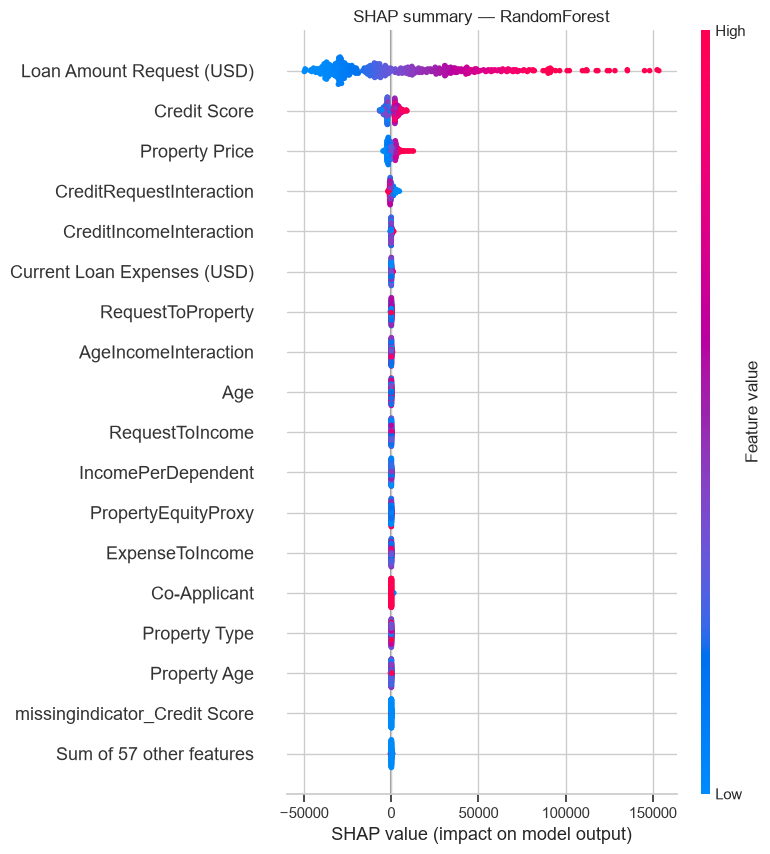

,feature,mean_abs_shap
2,Loan Amount Request (USD),"32,504.911"
5,Credit Score,"3,134.892"
10,Property Price,"1,944.084"
17,CreditRequestInteraction,871.067
16,CreditIncomeInteraction,99.155
3,Current Loan Expenses (USD),83.491
12,RequestToProperty,44.793
18,AgeIncomeInteraction,42.185
0,Age,36.782
11,RequestToIncome,34.594


In [6]:
import shap

preprocessor = pipeline.named_steps["preprocessor"]
estimator = pipeline.named_steps["model"]
sample_raw = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
background_raw = X_test.sample(min(150, len(X_test)), random_state=7)
sample_transformed = preprocessor.transform(sample_raw)
background_transformed = preprocessor.transform(background_raw)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(
    estimator,
    data=background_transformed[:100],
    feature_names=feature_names,
    feature_perturbation="interventional",
)
shap_values = explainer(sample_transformed, check_additivity=False)
shap.plots.beeswarm(shap_values, max_display=18, show=False)
plt.title(f"SHAP summary — {model_name}")
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
display(shap_importance.head(20))

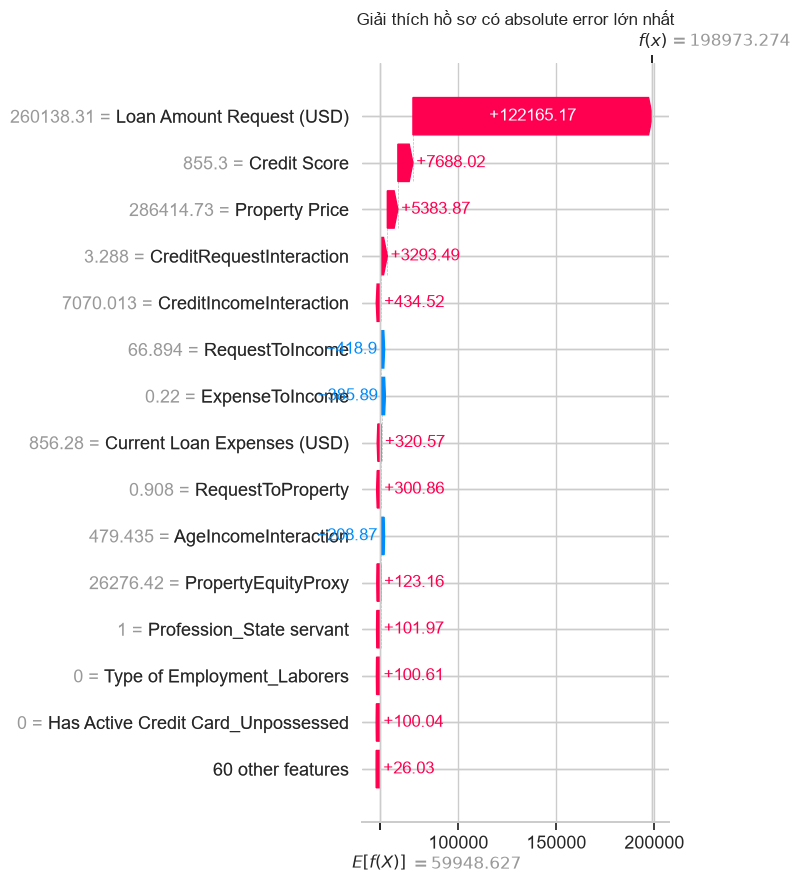

,Loan Amount Request (USD),Loan Sanction Amount (USD),prediction,residual,Credit Score,Income (USD),Property Price
source_index,,,,,,,
6132,"260,138.310","260,138.310","198,973.272","-61,165.038",855.300,"3,888.830","286,414.730"


In [7]:
row_position = int(np.argmax(predictions["absolute_error"].to_numpy()))
row_index = predictions.index[row_position]
row_raw = modeling_frame(predictions.loc[[row_index]])
row_transformed = preprocessor.transform(row_raw)
row_shap = explainer(row_transformed)
shap.plots.waterfall(row_shap[0], max_display=15, show=False)
plt.title("Giải thích hồ sơ có absolute error lớn nhất")
plt.tight_layout()
plt.show()

display(predictions.loc[[row_index], [REQUEST, TARGET, "prediction", "residual", "Credit Score", "Income (USD)", "Property Price"]])

## 3. Residual và hiệu suất theo phân khúc

In [8]:
def segment_metrics(frame, group_col):
    rows = []
    for group, part in frame.groupby(group_col, dropna=False, observed=True):
        m = regression_metrics(part[TARGET], part["prediction"], part[REQUEST])
        rows.append({"group": group, "n": len(part), **m})
    return pd.DataFrame(rows).sort_values("mae", ascending=False)

predictions["target_band"] = pd.qcut(predictions[TARGET], q=5, duplicates="drop")
predictions["credit_band"] = pd.cut(predictions["Credit Score"], bins=[0, 650, 700, 750, 800, 850, np.inf])
predictions["income_band"] = pd.qcut(predictions["Income (USD)"], q=5, duplicates="drop")

for column in ["target_band", "credit_band", "income_band", "Gender", "Location", "Income Stability"]:
    print(f"\nPhân khúc: {column}")
    display(segment_metrics(predictions, column))


Phân khúc: target_band


,group,n,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
4,"(99166.652, 323233.31]",644,"7,013.574","9,086.520",0.932,0.061,0.051,0.952,0.994,"-1,032.222",0.439,0.000
3,"(66871.32, 99166.652]",644,"3,672.317","4,331.660",0.772,0.054,0.045,0.966,0.997,68.107,0.478,0.000
2,"(46007.818, 66871.32]",643,"2,472.886","2,916.708",0.738,0.052,0.045,0.972,0.998,111.511,0.498,0.000
1,"(27070.808, 46007.818]",644,"1,648.783","1,929.957",0.890,0.054,0.047,0.958,0.998,77.001,0.495,0.000
0,"(4319.6089999999995, 27070.808]",644,871.973,"1,053.580",0.965,0.051,0.046,0.970,1.000,168.893,0.561,0.000



Phân khúc: credit_band


,group,n,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
5,"(850.0, inf]",233,"5,559.738","9,607.521",0.968,0.084,0.066,0.845,0.966,"-1,295.398",0.545,0.000
6,NaN,223,"4,087.401","5,974.399",0.982,0.074,0.065,0.789,1.000,690.973,0.587,0.000
4,"(800.0, 850.0]",657,"3,799.386","5,323.162",0.989,0.058,0.051,0.973,1.000,-175.238,0.487,0.000
3,"(750.0, 800.0]",720,"3,523.740","4,835.303",0.989,0.057,0.049,0.979,1.000,-284.235,0.471,0.000
2,"(700.0, 750.0]",703,"2,174.036","2,680.631",0.995,0.039,0.037,0.999,1.000,216.839,0.504,0.000
1,"(650.0, 700.0]",679,"1,948.304","2,386.037",0.996,0.038,0.036,1.000,1.000,-114.449,0.468,0.000
0,"(0.0, 650.0]",4,925.424,"1,081.868",0.976,0.042,0.043,1.000,1.000,490.318,0.500,0.000



Phân khúc: income_band


...

,group,n,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
0,F,1661,"3,228.335","5,030.409",0.988,0.056,0.049,0.964,0.996,-197.748,0.491,0.000
2,NaN,6,"3,206.768","4,130.283",0.973,0.056,0.050,1.000,1.000,-606.824,0.333,0.000
1,M,1552,"3,037.140","4,519.790",0.990,0.053,0.046,0.963,0.999,-37.843,0.498,0.000



Phân khúc: Location


,group,n,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
2,Urban,364,"3,884.844","5,621.016",0.989,0.054,0.046,0.973,0.997,270.373,0.522,0.000
1,Semi-Urban,2299,"3,104.359","4,823.501",0.988,0.055,0.048,0.963,0.997,-184.198,0.493,0.000
0,Rural,556,"2,777.235","3,989.474",0.991,0.052,0.045,0.960,1.000,-118.306,0.482,0.000



Phân khúc: Income Stability


,group,n,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
0,High,327,"3,490.366","5,083.633",0.988,0.067,0.053,0.930,0.988,-135.102,0.505,0.000
2,NaN,218,"3,202.989","4,513.449",0.989,0.053,0.048,0.972,1.000,-19.543,0.537,0.000
1,Low,2674,"3,087.339","4,774.156",0.989,0.053,0.047,0.967,0.999,-128.046,0.490,0.000


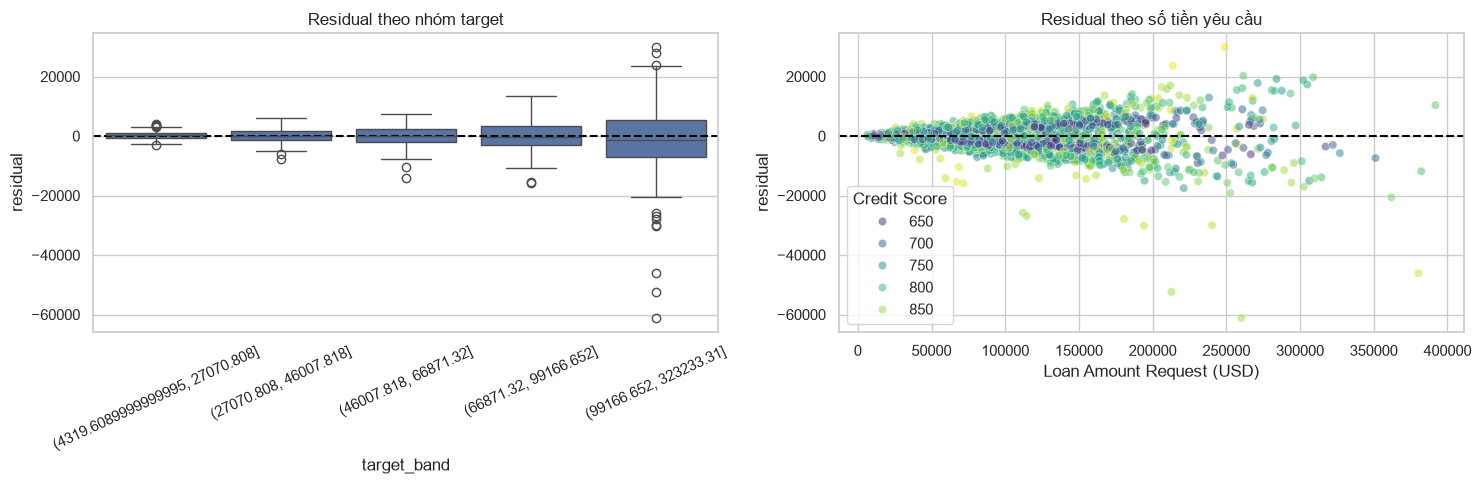

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=predictions, x="target_band", y="residual", ax=axes[0])
axes[0].tick_params(axis="x", rotation=25)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residual theo nhóm target")

sns.scatterplot(data=predictions, x=REQUEST, y="residual", hue="Credit Score", palette="viridis", alpha=.5, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residual theo số tiền yêu cầu")
plt.tight_layout()
plt.show()

## 4. Kết luận diễn giải

In [10]:
top_perm = perm_df.iloc[0]["feature"]
top_shap = shap_importance.iloc[0]["feature"]
gender_metrics = segment_metrics(predictions, "Gender")
gender_gap = gender_metrics["mae"].max() - gender_metrics["mae"].min()
worst_band = segment_metrics(predictions, "target_band").iloc[0]
display(Markdown(f"""
### Kết luận

- Feature quan trọng nhất theo permutation là **{top_perm}**; theo SHAP là **{top_shap}**.
- Nếu các feature liên quan số tiền yêu cầu đứng đầu, mô hình chủ yếu tái tạo policy sanction theo nhu cầu vay. Điều này phù hợp dữ liệu nhưng không chứng minh quan hệ nhân quả với khả năng trả nợ.
- Nhóm target có MAE cao nhất là **{worst_band['group']}**, MAE **{worst_band['mae']:,.0f} USD** trên {int(worst_band['n']):,} hồ sơ.
- Chênh lệch MAE quan sát giữa các nhóm giới tính là **{gender_gap:,.0f} USD**. Đây là audit hiệu suất, không đủ để kết luận fairness nếu chưa kiểm soát cấu trúc hồ sơ.
- Production model không dùng `Gender`; các biến vị trí vẫn cần theo dõi vì có thể đóng vai trò proxy.
"""))


### Kết luận

- Feature quan trọng nhất theo permutation là **Loan Amount Request (USD)**; theo SHAP là **Loan Amount Request (USD)**.
- Nếu các feature liên quan số tiền yêu cầu đứng đầu, mô hình chủ yếu tái tạo policy sanction theo nhu cầu vay. Điều này phù hợp dữ liệu nhưng không chứng minh quan hệ nhân quả với khả năng trả nợ.
- Nhóm target có MAE cao nhất là **(99166.652, 323233.31]**, MAE **7,014 USD** trên 644 hồ sơ.
- Chênh lệch MAE quan sát giữa các nhóm giới tính là **191 USD**. Đây là audit hiệu suất, không đủ để kết luận fairness nếu chưa kiểm soát cấu trúc hồ sơ.
- Production model không dùng `Gender`; các biến vị trí vẫn cần theo dõi vì có thể đóng vai trò proxy.
